In [1]:
#Load the data
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned listings into a pandas DataFrame
df = duckdb.sql(
    "SELECT * FROM read_parquet('../data/silver/nyc/listings.parquet')"
).df()

# Work with priced listings only for price analysis
priced = df[df["price"].notna()].copy()

# Label each listing by the length of its quoted stay
priced["stay_type"] = np.where(
    priced["quote_nights"] < 28, "short stay", "monthly stay"
)

print("All listings:   ", len(df))
print("Priced listings:", len(priced))

All listings:    30259
Priced listings: 21515


In [2]:
# What does a typical price look like?
# Percentiles show the whole spread, not just one "average"
percentiles = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
print(priced["price"].quantile(percentiles).round(2))

print()
print("Mean:  ", round(priced["price"].mean(), 2))
print("Median:", round(priced["price"].median(), 2))
print("Max:   ", round(priced["price"].max(), 2))
print("Listings above $1,000:", (priced["price"] > 1000).sum())

0.01      39.47
0.05      52.73
0.25      96.88
0.50     174.69
0.75     302.72
0.95     759.00
0.99    1713.94
Name: price, dtype: float64

Mean:   278.23
Median: 174.69
Max:    30972.96
Listings above $1,000: 622


<>:13: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
<>:13: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
C:\Users\win-11\AppData\Local\Temp\ipykernel_22244\2071083894.py:13: SyntaxWarning: "\$" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\$"? A raw string is also an option.
  axes[1].set_xlabel("log10(price)   [2 = \$100, 3 = \$1,000]")


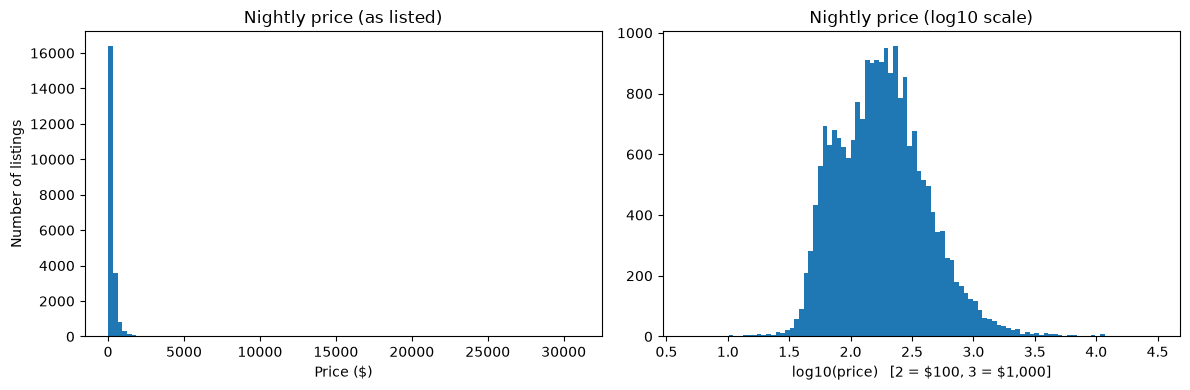

In [8]:
# See the shape
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: prices as they are
axes[0].hist(priced["price"], bins=100)
axes[0].set_title("Nightly price (as listed)")
axes[0].set_xlabel("Price ($)")
axes[0].set_ylabel("Number of listings")

# Right: the same prices on a log scale
axes[1].hist(np.log10(priced["price"]), bins=100)
axes[1].set_title("Nightly price (log10 scale)")
axes[1].set_xlabel("log10(price)   [2 = \$100, 3 = \$1,000]")

plt.tight_layout()
plt.show()

In [4]:
# Are short-stay and monthly prices different?
summary = priced.groupby("stay_type").agg(
    listings=("listing_id", "count"),
    median_price=("price", "median"),
    median_pre_discount=("pre_discount_nightly_price", "median"),
    pct_discounted=("quote_discount", lambda s: (s > 0).mean() * 100),
).round(1)

print(summary)
print()

# How room types are split between the two stay types
print(pd.crosstab(priced["room_type"], priced["stay_type"]))

              listings  median_price  median_pre_discount  pct_discounted
stay_type                                                                
monthly stay     16522         142.8                160.7            52.8
short stay        4993         308.5                313.0             7.4

stay_type        monthly stay  short stay
room_type                                
Entire home/apt          9948        1589
Hotel room                 21         459
Private room             6401        2905
Shared room               152          40


stay_type        monthly stay  short stay
room_type                                
Entire home/apt         202.0       403.0
Hotel room              399.0       447.0
Private room             77.0       248.0
Shared room              47.0       270.0


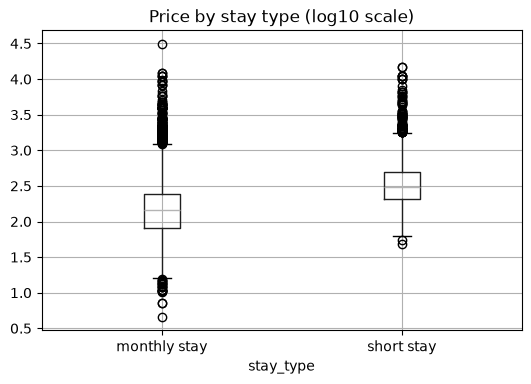

In [5]:
# Median price by room type and stay type
pivot = priced.pivot_table(
    index="room_type",
    columns="stay_type",
    values="price",
    aggfunc="median",
).round(0)
print(pivot)

# Box plot on a log scale to compare spreads
priced.assign(log10_price=np.log10(priced["price"])).boxplot(
    column="log10_price", by="stay_type", figsize=(6, 4)
)
plt.suptitle("")
plt.title("Price by stay type (log10 scale)")
plt.show()

In [6]:
# Are priced listings different from unpriced ones?
df["has_price"] = df["price"].notna()

comparison = df.groupby("has_price").agg(
    listings=("listing_id", "count"),
    median_min_nights=("minimum_nights", "median"),
    median_availability_365=("availability_365", "median"),
    median_reviews_last_12m=("number_of_reviews_ltm", "median"),
    pct_superhost=("host_is_superhost", lambda s: s.eq(True).mean() * 100),
).round(1)
print(comparison)
print()

# Room type share (%) within priced and unpriced listings
print(
    pd.crosstab(df["room_type"], df["has_price"], normalize="columns")
    .mul(100).round(1)
)

           listings  median_min_nights  median_availability_365  \
has_price                                                         
False          8744               30.0                      0.0   
True          21515               30.0                    272.0   

           median_reviews_last_12m  pct_superhost  
has_price                                          
False                          0.0            6.3  
True                           0.0           30.8  

has_price        False  True 
room_type                    
Entire home/apt   60.3   53.6
Hotel room         0.5    2.2
Private room      39.0   43.3
Shared room        0.3    0.9


In [7]:
# Look at the most expensive listings
top = priced.nlargest(10, "price")[[
    "listing_id", "room_type", "property_type", "accommodates",
    "bedrooms", "quote_nights", "price", "pre_discount_nightly_price",
]]
print(top)

print()
for limit in [1000, 2000, 5000, 10000]:
    print(f"Listings above ${limit:,}:", (priced["price"] > limit).sum())

                listing_id        room_type                property_type  \
29997  1685032623471298360  Entire home/apt           Entire rental unit   
22075  1111666023012679487       Hotel room                Room in hotel   
22076  1111666150326773564       Hotel room                Room in hotel   
798                 990529     Private room  Private room in rental unit   
731                1623431     Private room  Private room in rental unit   
18011   830656153550799267  Entire home/apt                        Tower   
18034   830682282357157632  Entire home/apt                        Tower   
28450  1614018340350324380     Private room                Room in hotel   
28451  1614018632211285219     Private room                Room in hotel   
28452  1614018927799603136     Private room                Room in hotel   

       accommodates  bedrooms  quote_nights     price  \
29997            14       7.0            30  30972.96   
22075             5       2.0             1  1486

In [9]:
# Does registration explain the short-stay premium?
# Group the license column into three simple statuses
license_text = priced["license"].fillna("").str.lower()

priced["license_status"] = np.select(
    [license_text == "", license_text.str.contains("exempt")],
    ["no license", "exempt"],
    default="registration number",
)

# Share of each status within each stay type (rows add up to 100%)
print(
    pd.crosstab(priced["stay_type"], priced["license_status"], normalize="index")
    .mul(100).round(1)
)
print()

# Median price for each combination
print(
    priced.pivot_table(index="stay_type", columns="license_status",
                       values="price", aggfunc="median").round(0)
)

license_status  exempt  no license  registration number
stay_type                                              
monthly stay       0.4        99.3                  0.3
short stay        50.5         5.9                 43.7

license_status  exempt  no license  registration number
stay_type                                              
monthly stay     518.0       143.0                144.0
short stay       402.0       329.0                238.0


In [10]:
# Repeated identical high prices
high = priced[priced["price"] > 2000]

repeated = (
    high.groupby(["host_id", "price"])
    .size()
    .reset_index(name="listings_with_same_price")
    .query("listings_with_same_price > 1")
    .sort_values("listings_with_same_price", ascending=False)
)
print(repeated.head(10))
print()
print("High-priced listings sharing an exact price with the same host:",
      repeated["listings_with_same_price"].sum())

       host_id     price  listings_with_same_price
1       836168   2765.47                         4
117  566778653  10986.00                         4
57   266989293  10000.00                         3
98   501999278   2015.00                         3
81   465579714   2046.43                         3
79   446820235   3949.10                         3
22    26556695   3081.00                         2
40    76166434  11061.80                         2
0       836168   2212.37                         2
86   465579714   4535.33                         2

High-priced listings sharing an exact price with the same host: 52
